In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scipy

In [6]:
# Import necessary libraries
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head(2)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


2. Have you computed the correlation between “Age” and other numerical columns such as “CompTotal” and “YearsCodePro”?

In [9]:
df["Age"].value_counts()

Age
25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322
Name: count, dtype: int64

In [10]:
import numpy as np
def years_to_numeric(value):
    if pd.isna(value):
        return np.nan
    if value == 'Less than 1 year':
        return 0.5
    if value == 'More than 50 years':
        return 51
    return float(value)

age_order = {'Under 18 years old': 1,
             '18-24 years old': 2,
             '25-34 years old': 3,
             '35-44 years old': 4,
             '45-54 years old': 5,
             '55-64 years old': 6,
             '65 years or older': 7
            }

df['Age_Rank'] = df['Age'].map(age_order)

df['YearsCodePro_Num'] = df['YearsCodePro'].apply(years_to_numeric)

df_correlation = df[["YearsCodePro_Num","Age_Rank"]].dropna()

pearson_corr = df_correlation['YearsCodePro_Num'].corr(df_correlation['Age_Rank'], method='pearson')
spearman_corr = df_correlation['YearsCodePro_Num'].corr(df_correlation['Age_Rank'], method='spearman')

print(f"Pearson correlation: {pearson_corr:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")
df_correlation[['YearsCodePro_Num', 'Age_Rank']].corr()

Pearson correlation: 0.8262
Spearman correlation: 0.8054


,YearsCodePro_Num,Age_Rank
YearsCodePro_Num,1.000000,0.826245
Age_Rank,0.826245,1.000000


3. Have you plotted a histogram for the “Age” column to understand its distribution?

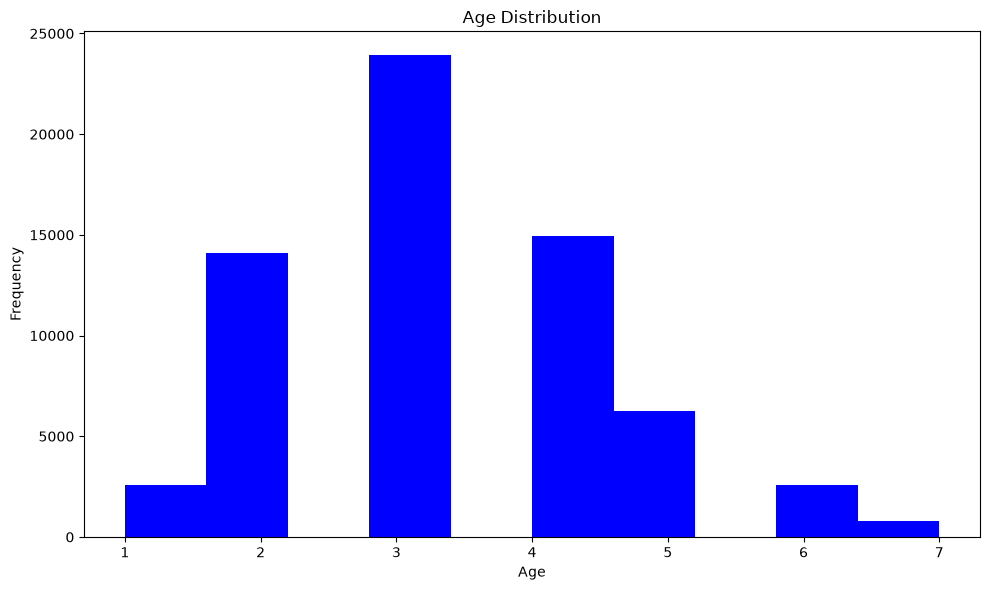

In [19]:
plt.figure(figsize=(10, 6))

plt.hist(df['Age_Rank'],color = "blue", bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [21]:
# Select a numeric column
col = df['YearsCodePro_Num'].dropna()

# Calculate quartiles
Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")


Q1: 3.0
Q3: 15.0
IQR: 12.0
Lower Bound: -15.0
Upper Bound: 33.0


In [22]:
outliers = df[
    (df['YearsCodePro_Num'] < lower_bound) |
    (df['YearsCodePro_Num'] > upper_bound)
]

print(f"Number of outliers: {len(outliers)}")
print(outliers[['YearsCodePro_Num']].head())

Number of outliers: 1420
     YearsCodePro_Num
23               37.0
48               45.0
92               37.0
113              35.0
134              45.0


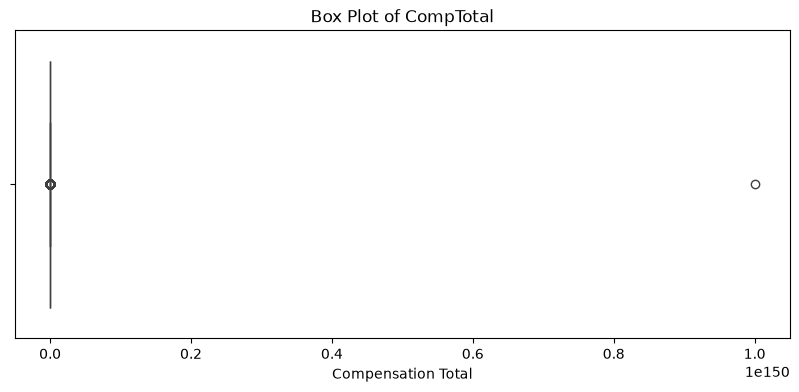

In [23]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['CompTotal'])

plt.title('Box Plot of CompTotal')
plt.xlabel('Compensation Total')
plt.show()

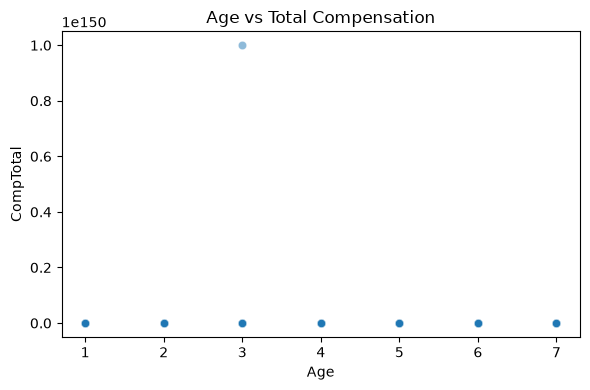

In [28]:
scatter_df = df[['Age_Rank', 'CompTotal']].dropna()

plt.figure(figsize=(6, 4))
sns.scatterplot(data=scatter_df, x='Age_Rank', y='CompTotal',alpha=0.5)

plt.title('Age vs Total Compensation')
plt.xlabel('Age')
plt.ylabel('CompTotal')
plt.tight_layout()
plt.show()

In [29]:
df.head(15)

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,YearsCodePro_Num,Age_Rank
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,17.0,4.0
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN,27.0,5.0
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN,NaN,2.0
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN,NaN,2.0
5,6,I code primarily as a hobby,Under 18 years old,"Student, full-time",NaN,Apples,NaN,Primary/elementary school,"School (i.e., University, College, etc);Online...",NaN,...,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN,NaN,1.0
6,7,"I am not primarily a developer, but I write co...",35-44 years old,"Employed, full-time",Remote,Apples,I don’t code outside of work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Other online resources (e.g., videos, blogs, f...",Technical documentation;Stack Overflow;Written...,...,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN,NaN,7.0,4.0
7,8,I am learning to code,18-24 years old,"Student, full-time;Not employed, but looking f...",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Video-based Online Cou...,...,NaN,NaN,NaN,NaN,Appropriate in length,Difficult,NaN,NaN,NaN,2.0
8,9,I code primarily as a hobby,45-54 years old,"Employed, full-time",In-person,Apples,Hobby,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Books / Physical media;Other online resources ...,Stack Overflow;Written-based Online Courses,...,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,NaN,NaN,5.0
9,10,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN,11.0,4.0
